for the dataset, download the val folder from https://www.kaggle.com/competitions/imagenet-object-localization-challenge/data
This did require some workaround for me. I had to log into kaggle, create a "notebook" as part of the the imagenet-object-localization-challenge, then run:  
```!zip -r -j /kaggle/working/imagenet_val_dataset.zip /kaggle/input/competitions/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val```  
then run:  
```from IPython.display import FileLink```  
```FileLink(r"imagenet_val_dataset.zip")```  
in order to download

If you have/make a kaggle account, I can also share my notebook, which should let you download too, or just run those commands yourself

Make sure to host the files in their own folder within your local clone of this repo. Also, MAKE SURE TO ADD THE FOLDER NAME TO THE GITIGNORE!!! I used the folder name "imagenet_val_dataset", so that should already be in the .gitignore file.

# Setup

In [ ]:
# if you've already installed, don't need to install again

#!python -m pip install torch torchvision
#!python -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 6.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 6.3 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 6.6 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 6.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.8 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.3 MB 2.5 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 3.9 MB/s  0:00:00
U

In [1]:
# importing different modules
# numpy is for math and matrix/vector stuff
# matplotlib is for visualizing data
# PIL allows for opening image files
# torchvision and torch are for ML handling
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import torch



In [2]:
# Defining the different models, using pretrained weights
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
resnet = models.resnet34(weights = models.ResNet34_Weights.DEFAULT)
convnext = models.convnext_base(weights = models.ConvNeXt_Base_Weights.DEFAULT)

# Setting the models to evaluation mode
alexnet.eval()
resnet.eval()
convnext.eval()

# Get the preprocessing transformations necessary in order for the models to take the image inputs
alex_preprocess = models.AlexNet_Weights.DEFAULT.transforms()
res_preprocess = models.ResNet34_Weights.DEFAULT.transforms()
conv_preprocess = models.ConvNeXt_Base_Weights.DEFAULT.transforms()

# Attempt for single image

In [3]:
input_image = Image.open("imagenet_val_dataset/ILSVRC2012_val_00000001.JPEG")

#preprocess the image to put in the model
alex_input = alex_preprocess(input_image)
res_input = res_preprocess(input_image)
conv_input = conv_preprocess(input_image)
alex_batch = alex_input.unsqueeze(0)
res_batch = res_input.unsqueeze(0)
conv_batch = conv_input.unsqueeze(0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..1.9776908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..1.9776908].


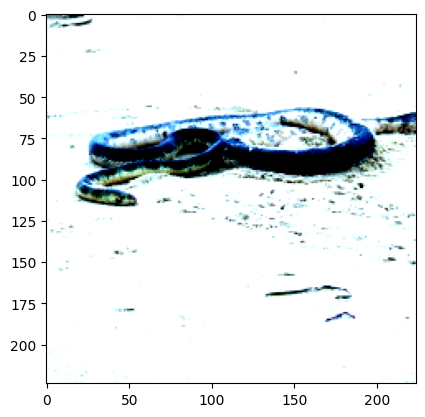

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..1.9602616].


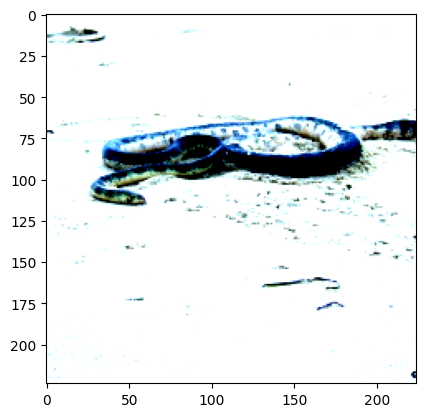

In [4]:
# display the preprocessed image using matplotlib
for img in alex_batch:
    img_np = img.numpy()
    img_np = img_np.transpose(1,2,0)
    plt.imshow(img_np)
    plt.show
for img in res_batch:
    img_np = img.numpy()
    img_np = img_np.transpose(1,2,0)
    plt.imshow(img_np)
    plt.show()
for img in conv_batch:
    img_np = img.numpy()
    img_np = img_np.transpose(1,2,0)
    plt.imshow(img_np)
    plt.show()

In [5]:
## taken from pytorch forums
# creates an array of class labels where idx2label[i] is the string label associated with class i
import json
class_idx = json.load(open("imagenet_class_index.json"))
idx2label = np.array([class_idx[str(k)][1] for k in range(len(class_idx))])
#print(idx2label)
def convertIndexToLabel(i):
    return idx2label[i]

# using the imagenet official correct validation classifications, turns those class numbers into a list of classification names
# these are the "correct" classes for each image in the dataset
file_path = 'val.txt'
true_class_nums = np.loadtxt(file_path, dtype = int)
true_class_names = convertIndexToLabel(true_class_nums)
#print(true_class_nums[100:130].tolist())
#print(true_class_names[100:130].tolist())


In [6]:
# inputs the preprocessed data into the models
with torch.no_grad():
    alexoutput = alexnet(alex_batch)
    resoutput = resnet(res_batch)
    convoutput = convnext(conv_batch)

# takes the outputs and uses the softmax function to bound the raw values to the range [0,1]
# this makes them act as class "probabilities" (not really probabilities, which is something I'm very interested in)
# these "probabilities" sum to 1 across all classes
alexprob = torch.nn.functional.softmax(alexoutput[0], dim=0)
resprob = torch.nn.functional.softmax(resoutput[0], dim=0)
convprob = torch.nn.functional.softmax(convoutput[0], dim=0)

# orders the class labels for each class as well as the class "probabilities" in order of highest to lowest
alex_prob_label = sorted(zip(alexprob, idx2label), reverse = True)
res_prob_label = sorted(zip(resprob, idx2label), reverse = True)
conv_prob_label = sorted(zip(convprob, idx2label), reverse = True)
sorted_alex_prob, sorted_alex_label = zip(*list(alex_prob_label))
sorted_res_prob, sorted_res_label = zip(*list(res_prob_label))
sorted_conv_prob, sorted_conv_label = zip(*list(conv_prob_label))



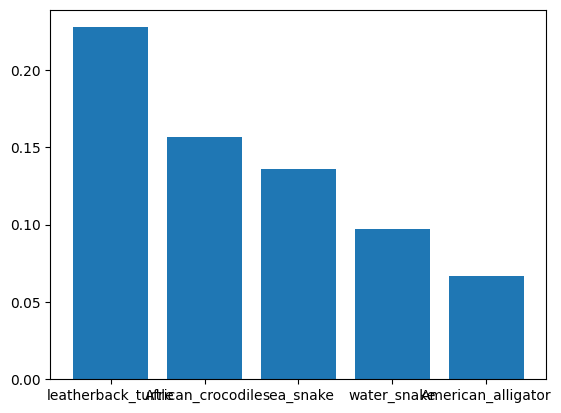

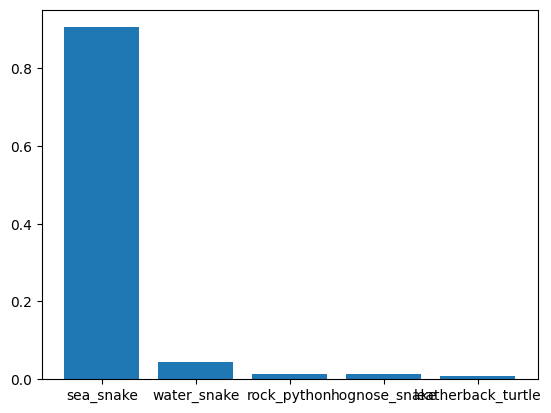

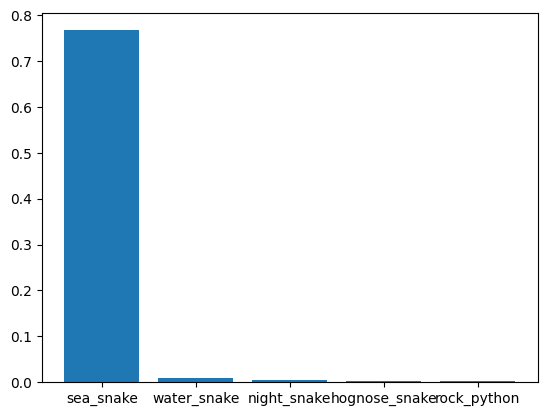

In [7]:
# displays the top 5 highest labels for each model, and their associated "probabilities"
plt.bar(sorted_alex_label[:5], sorted_alex_prob[:5])
plt.title("")
plt.show()
plt.bar(sorted_res_label[:5], sorted_res_prob[:5])
plt.show()
plt.bar(sorted_conv_label[:5], sorted_conv_prob[:5])
plt.show()

# Attempt for running on multiple images

In [ ]:
import os
import sys

# setup that allows us to iterate through the different models
class modelinfo:
    def __init__(self, model, preprocess):
        self.model = model
        self.preprocess = preprocess
alexinfo = modelinfo(alexnet, alex_preprocess)
resinfo = modelinfo(resnet, res_preprocess)
convinfo = modelinfo(convnext, conv_preprocess)
used_models = [alexinfo, resinfo, convinfo]

# this is my former file location for the validation dataset. Replace with your validation dataset folder/location
files = os.listdir("C:/Users/skyei/Desktop/massai-interpretability/Skye_Starter_CNN_Code/imagenet_val_dataset")

# params to determine which slice of the validation set (or whatever set we're using) we're looking at
start = 0
num_iter = 100

# iterates through the models, and for each model, will run all the images from start to start+num_iter through the model
# it will then add the labels, and images (as numpy array) to associated arrays for further analysis
model_labels = []
model_np_imgs = []
flag = True
for model in used_models:
    print(model.model._get_name())
    labels = []
    for i, file in enumerate(files[start:min(len(files),start+num_iter)]):
        # code for making countdown
        print(f"\r{i+1}/{num_iter}", end="")
        sys.stdout.flush()

        # running the file through the models
        if file[-5:] == ".JPEG":
            img = Image.open("imagenet_val_dataset/"+file)
            #img.convert("RGB") is important because some images are in black-and-white,
            #which means they have a different tensor size as colored images, since they 
            #are missing a color channel
            input = model.preprocess(img.convert("RGB")).unsqueeze(0)
            # gets the "probability" for each class
            prob = torch.nn.functional.softmax(model.model(input)[0], dim=0)
            # sorts the class labels in order from highest to lowest "probability"
            sorted_prob_label = sorted(zip(prob, idx2label), reverse = True)
            sorted_prob, sorted_label = zip(*list(sorted_prob_label))
            # gets the predicted label
            label = sorted_label[0]
            labels.append(label)
            # adds a copy of the image so we can display alongside data below
            if(flag):
                img_np = np.array(img)
                model_np_imgs.append(img_np)
    model_labels.append(labels)
    flag = False
    print("")

AlexNet
100/100
ResNet
100/100
ConvNeXt
100/100


In [10]:
# for every image where the models disagree, or where the true label is different from that of the images
# this code will display the image number, the predicted labels, and the true label
diffidxs = []
difflabels = []
diffs = []
for i, (alabel, rlabel, clabel) in enumerate(zip(model_labels[0],model_labels[1],model_labels[2])):
    truelabel = true_class_names[i+start]
    if (not alabel == rlabel == clabel) or alabel != truelabel:
        diffidxs.append(i)
        difflabels.append((alabel, rlabel, clabel))
        diffs.append((i+start, alabel, rlabel, clabel))
        print( "Image:",i+start, "AlexNet:", alabel, "ResNet:", rlabel, "ConvNeXt:", clabel, "Actually:", truelabel)
        # Commenting these out to be able to see the next code below. Re-enable to see images.
        #plt.imshow(model_np_imgs[i])
        #plt.show()
        

print(diffs)

Image: 0 AlexNet: leatherback_turtle ResNet: sea_snake ConvNeXt: sea_snake Actually: sea_snake
Image: 1 AlexNet: ski ResNet: ski ConvNeXt: ski Actually: alp
Image: 3 AlexNet: cup ResNet: soup_bowl ConvNeXt: soup_bowl Actually: soup_bowl
Image: 4 AlexNet: beagle ResNet: cradle ConvNeXt: crib Actually: cradle
Image: 5 AlexNet: diamondback ResNet: sea_snake ConvNeXt: garter_snake Actually: garter_snake
Image: 7 AlexNet: bath_towel ResNet: tennis_ball ConvNeXt: ice_cream Actually: bakery
Image: 8 AlexNet: fox_squirrel ResNet: mousetrap ConvNeXt: mousetrap Actually: mousetrap
Image: 9 AlexNet: Maltese_dog ResNet: Maltese_dog ConvNeXt: Angora Actually: Angora
Image: 16 AlexNet: quill ResNet: starfish ConvNeXt: starfish Actually: sea_anemone
Image: 17 AlexNet: kite ResNet: kite ConvNeXt: vulture Actually: vulture
Image: 18 AlexNet: desk ResNet: carton ConvNeXt: carton Actually: carton
Image: 21 AlexNet: stretcher ResNet: English_foxhound ConvNeXt: Ibizan_hound Actually: Ibizan_hound
Image: 27

In [22]:
print(model_labels[0])
print(true_class_names[start:])

[np.str_('leatherback_turtle'), np.str_('ski'), np.str_('Shetland_sheepdog'), np.str_('cup'), np.str_('beagle'), np.str_('diamondback'), np.str_('porcupine'), np.str_('bath_towel'), np.str_('fox_squirrel'), np.str_('Maltese_dog'), np.str_('brain_coral'), np.str_('cougar'), np.str_('guenon'), np.str_('recreational_vehicle'), np.str_('harvester'), np.str_('grey_whale'), np.str_('quill'), np.str_('kite'), np.str_('desk'), np.str_('crane'), np.str_('porcupine'), np.str_('stretcher'), np.str_('Granny_Smith'), np.str_('planetarium'), np.str_('vulture'), np.str_('table_lamp'), np.str_('white_wolf'), np.str_('Walker_hound'), np.str_('green_snake'), np.str_('recreational_vehicle'), np.str_('cabbage_butterfly'), np.str_('go-kart'), np.str_('otter'), np.str_('ballplayer'), np.str_('half_track'), np.str_('vestment'), np.str_('slug'), np.str_('abacus'), np.str_('sewing_machine'), np.str_('bee'), np.str_('bassinet'), np.str_('rain_barrel'), np.str_('spoonbill'), np.str_('miniature_schnauzer'), np.st

In [37]:
misclass_pics = []
misclass_count = []
for j in range(len(model_labels)):
    misclass_count.append(0)
    misclass_pics.append([])
    for i, label in enumerate(model_labels[j]):
        truelabel = true_class_names[i+start]
        if label != truelabel:
            misclass_count[j] += 1
            num_zeros = 7
            count = i+1
            for n in range(1,9):
                #print(count)
                if count // 10 != 0:
                    count = count // 10
                    num_zeros -= 1
                else:
                    break
            #print(num_zeros)
            misclass_pics[j].append("ILSVRC2012_val_%s%d.JPEG" % (num_zeros*"0", i+1))
print(misclass_pics)
print(misclass_count)
#accuracy
total_classified = len(model_labels[0])
accuracy = ((np.zeros(3)+total_classified)-np.array(misclass_count))/total_classified
print(accuracy)

    

[['ILSVRC2012_val_00000001.JPEG', 'ILSVRC2012_val_00000002.JPEG', 'ILSVRC2012_val_00000004.JPEG', 'ILSVRC2012_val_00000005.JPEG', 'ILSVRC2012_val_00000006.JPEG', 'ILSVRC2012_val_00000008.JPEG', 'ILSVRC2012_val_00000009.JPEG', 'ILSVRC2012_val_00000010.JPEG', 'ILSVRC2012_val_00000017.JPEG', 'ILSVRC2012_val_00000018.JPEG', 'ILSVRC2012_val_00000019.JPEG', 'ILSVRC2012_val_00000022.JPEG', 'ILSVRC2012_val_00000028.JPEG', 'ILSVRC2012_val_00000030.JPEG', 'ILSVRC2012_val_00000033.JPEG', 'ILSVRC2012_val_00000037.JPEG', 'ILSVRC2012_val_00000039.JPEG', 'ILSVRC2012_val_00000040.JPEG', 'ILSVRC2012_val_00000041.JPEG', 'ILSVRC2012_val_00000044.JPEG', 'ILSVRC2012_val_00000045.JPEG', 'ILSVRC2012_val_00000048.JPEG', 'ILSVRC2012_val_00000050.JPEG', 'ILSVRC2012_val_00000055.JPEG', 'ILSVRC2012_val_00000059.JPEG', 'ILSVRC2012_val_00000061.JPEG', 'ILSVRC2012_val_00000062.JPEG', 'ILSVRC2012_val_00000063.JPEG', 'ILSVRC2012_val_00000064.JPEG', 'ILSVRC2012_val_00000065.JPEG', 'ILSVRC2012_val_00000069.JPEG', 'ILSVR

# Future Steps

* writing code to capture image misclassification cases (image number, predicted label, correct label)
* running code on full dataset in order to make a subset with only the misclassified images
* writing code to add gaussian noise to image(s)
* testing accuracy at different gaussian noise levels of misclassified images: do any become correctly classified? If so, how often?